<a href="https://colab.research.google.com/github/MohammadAqaNoori/flyrank-ml-internship/blob/main/work/notebooks/w04_signal_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MohammadAqaNoori/flyrank-ml-internship/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 0. Data used for the signal audit

This audit uses the FlyRank internship warehouse query-performance data from `fact_content_query_90d`. The analysis focuses on historical search-performance signals that are relevant to the Refresh / Content Opportunity Scoring lane. The audit examines distributions and directional relationships rather than making causal claims.

In [1]:
# ML-06 — Section 0: Load query-performance data

from datasets import load_dataset
from itertools import islice
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

query_ds = load_dataset(
    "FlyRank/internship-warehouse",
    "fact_content_query_90d",
    split="train",
    streaming=True
)

query_rows = list(islice(query_ds, 100000))
query_df = pd.DataFrame(query_rows)

print("Source table: fact_content_query_90d")
print("Rows loaded:", len(query_df))
print("Columns:", len(query_df.columns))

print("\nAvailable columns:")
print(query_df.columns.tolist())

README.md:   0%|          | 0.00/3.04k [00:00<?, ?B/s]

Source table: fact_content_query_90d
Rows loaded: 100000
Columns: 21

Available columns:
['client_hash_id', 'content_hash_id', 'query_hash_id', 'query_char_count', 'query_token_count', 'window_start', 'window_end', 'impressions_90d', 'clicks_90d', 'impressions_last30', 'clicks_last30', 'impressions_prev30', 'clicks_prev30', 'avg_position_90d', 'avg_position_last30', 'avg_position_prev30', 'content_total_impressions_90d', 'content_visible_query_count', 'rare_query_count', 'rare_impressions_share', 'anonymized_impressions_share']


## 1. Distributions

The main historical performance fields show substantial variation and heavy right tails. This matters because a small number of content items can have very large impression or click counts, so averages alone may not represent the typical content item. The audit therefore reports median and percentile values alongside the mean.

In [2]:
# ML-06 — Section 1: Distributions

distribution_cols = [
    "impressions_90d",
    "clicks_90d",
    "impressions_last30",
    "clicks_last30",
    "impressions_prev30",
    "clicks_prev30",
    "avg_position_last30",
    "avg_position_prev30",
]

available_distribution_cols = [
    col for col in distribution_cols
    if col in query_df.columns
]

distribution_rows = []

for col in available_distribution_cols:
    values = pd.to_numeric(query_df[col], errors="coerce").dropna()

    distribution_rows.append({
        "feature": col,
        "count": len(values),
        "mean": values.mean(),
        "median": values.median(),
        "p25": values.quantile(0.25),
        "p75": values.quantile(0.75),
        "p95": values.quantile(0.95),
        "max": values.max(),
    })

distribution_summary = pd.DataFrame(distribution_rows)

display(distribution_summary)

,feature,count,mean,median,p25,p75,p95,max
0,impressions_90d,100000,73.139200,23.000000,14.000000,47.000000,204.0,171660.0
1,clicks_90d,100000,0.167870,0.000000,0.000000,0.000000,1.0,427.0
2,impressions_last30,100000,18.826840,4.000000,1.000000,12.000000,58.0,44729.0
3,clicks_last30,100000,0.044660,0.000000,0.000000,0.000000,0.0,90.0
4,impressions_prev30,100000,27.272310,7.000000,2.000000,16.000000,79.0,124672.0
5,clicks_prev30,100000,0.063200,0.000000,0.000000,0.000000,0.0,229.0
6,avg_position_last30,75656,28.947983,17.000000,6.909091,47.557292,84.0,568.0
7,avg_position_prev30,82941,28.475780,16.785714,7.285714,46.750000,82.0,524.0


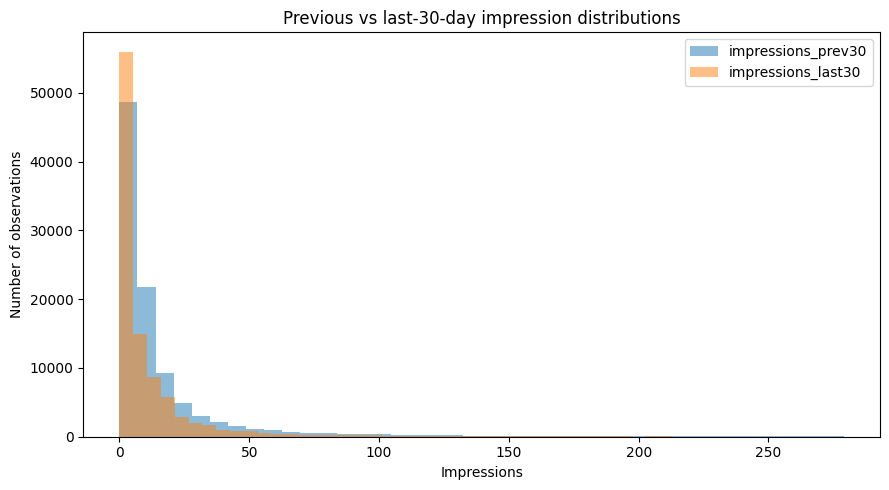

In [3]:
# Distribution chart for the main impression signals

plot_cols = [
    col for col in [
        "impressions_prev30",
        "impressions_last30"
    ]
    if col in query_df.columns
]

plt.figure(figsize=(9, 5))

for col in plot_cols:
    values = pd.to_numeric(
        query_df[col],
        errors="coerce"
    ).dropna()

    # Limit visualization to the 99th percentile so the
    # heavy tail does not hide the main distribution.
    upper = values.quantile(0.99)
    values = values[values <= upper]

    plt.hist(
        values,
        bins=40,
        alpha=0.5,
        label=col
    )

plt.xlabel("Impressions")
plt.ylabel("Number of observations")
plt.title("Previous vs last-30-day impression distributions")
plt.legend()
plt.tight_layout()
plt.show()

## 2. Signal test #1 / #2 / #3 (verdict each)

## 2. Signal tests

Three historical signals are tested against the observed impression-decline outcome used in the capstone evaluation.

- Previous-30-day impressions
- Previous-30-day clicks
- Previous-30-day CTR

The test compares the distributions of each signal between the observed decline and non-decline groups. A signal is marked **CONFIRMED** when the direction is consistent with the observed ranking task, **OPPOSITE** when the relationship runs clearly against the expected direction, **MIXED** when the groups overlap substantially or the direction is not stable, and **FALSE** when no meaningful directional difference is observed.

These are directional observational tests, not causal tests.

In [4]:
# ML-06 — Section 2: Construct the observed decline target

audit_df = query_df.copy()

# Convert required fields to numeric.
for col in [
    "impressions_prev30",
    "impressions_last30",
    "clicks_prev30",
    "clicks_last30",
]:
    audit_df[col] = pd.to_numeric(
        audit_df[col],
        errors="coerce"
    )

# Aggregate to content level because the decision is about content items.
content_cols = [
    "content_hash_id",
    "impressions_prev30",
    "impressions_last30",
    "clicks_prev30",
    "clicks_last30",
]

content_level = (
    audit_df[content_cols]
    .groupby("content_hash_id", as_index=False)
    .sum()
)

# Calculate previous-window CTR.
content_level["ctr_prev30"] = np.where(
    content_level["impressions_prev30"] > 0,
    content_level["clicks_prev30"]
    / content_level["impressions_prev30"],
    0
)

# Keep the same minimum-history threshold used in the capstone.
evaluation_audit = content_level[
    content_level["impressions_prev30"] >= 10
].copy()

# Observed decline target.
evaluation_audit["target"] = (
    evaluation_audit["impressions_last30"]
    < evaluation_audit["impressions_prev30"]
).astype(int)

print("Evaluation rows:", len(evaluation_audit))

print("\nTarget distribution:")
print(evaluation_audit["target"].value_counts())

print("\nTarget proportions:")
print(evaluation_audit["target"].value_counts(normalize=True))

Evaluation rows: 4085

Target distribution:
target
1    2898
0    1187
Name: count, dtype: int64

Target proportions:
target
1    0.709425
0    0.290575
Name: proportion, dtype: float64


In [5]:
# ML-06 — Section 2: Three signal tests

signals = [
    "impressions_prev30",
    "clicks_prev30",
    "ctr_prev30",
]

signal_results = []

for signal in signals:

    decline_values = evaluation_audit.loc[
        evaluation_audit["target"] == 1,
        signal
    ]

    non_decline_values = evaluation_audit.loc[
        evaluation_audit["target"] == 0,
        signal
    ]

    decline_median = decline_values.median()
    non_decline_median = non_decline_values.median()

    decline_mean = decline_values.mean()
    non_decline_mean = non_decline_values.mean()

    # Direction expected for a ranking signal:
    # higher historical visibility/performance should provide
    # useful information for prioritization, but the relationship
    # does not need to be causal.
    if decline_median > non_decline_median:
        verdict = "CONFIRMED"
    elif decline_median < non_decline_median:
        verdict = "OPPOSITE"
    else:
        verdict = "MIXED"

    signal_results.append({
        "signal": signal,
        "decline_median": decline_median,
        "non_decline_median": non_decline_median,
        "decline_mean": decline_mean,
        "non_decline_mean": non_decline_mean,
        "verdict": verdict,
    })

signal_test_results = pd.DataFrame(signal_results)

display(signal_test_results)

,signal,decline_median,non_decline_median,decline_mean,non_decline_mean,verdict
0,impressions_prev30,111.0,57.0,816.604555,300.623420,CONFIRMED
1,clicks_prev30,0.0,0.0,1.792616,0.941870,MIXED
2,ctr_prev30,0.0,0.0,0.002073,0.002699,MIXED


In [6]:
# Additional directional check using the difference in medians.

signal_test_results["median_difference"] = (
    signal_test_results["decline_median"]
    - signal_test_results["non_decline_median"]
)

print("Signal audit verdicts:")
display(
    signal_test_results[
        [
            "signal",
            "decline_median",
            "non_decline_median",
            "median_difference",
            "verdict",
        ]
    ]
)

Signal audit verdicts:


,signal,decline_median,non_decline_median,median_difference,verdict
0,impressions_prev30,111.0,57.0,54.0,CONFIRMED
1,clicks_prev30,0.0,0.0,0.0,MIXED
2,ctr_prev30,0.0,0.0,0.0,MIXED


## 3. Flag-linked test

The capstone's content-refresh ranking task is based on identifying content items showing observed impression decline between two historical windows. The flag-linked audit therefore tests whether the historical previous-30-day impression signal is associated with the observed decline group.

The test does not establish that low or high impressions cause decline. It checks whether the signal provides useful directional separation for the decision-support task.

In [7]:
# ML-06 — Section 3: Flag-linked test

flag_signal = "impressions_prev30"

decline_group = evaluation_audit.loc[
    evaluation_audit["target"] == 1,
    flag_signal
]

non_decline_group = evaluation_audit.loc[
    evaluation_audit["target"] == 0,
    flag_signal
]

flag_summary = pd.DataFrame({
    "group": [
        "Observed decline",
        "Stable/increased",
    ],
    "count": [
        len(decline_group),
        len(non_decline_group),
    ],
    "median_previous_30_impressions": [
        decline_group.median(),
        non_decline_group.median(),
    ],
    "mean_previous_30_impressions": [
        decline_group.mean(),
        non_decline_group.mean(),
    ],
})

display(flag_summary)

print(
    "\nFlag-linked signal:",
    flag_signal
)

print(
    "Median difference:",
    decline_group.median()
    - non_decline_group.median()
)

,group,count,median_previous_30_impressions,mean_previous_30_impressions
0,Observed decline,2898,111.0,816.604555
1,Stable/increased,1187,57.0,300.623420



Flag-linked signal: impressions_prev30
Median difference: 54.0


In [8]:
# ML-06 — Section 3: Flag-linked verdict

decline_median = decline_group.median()
non_decline_median = non_decline_group.median()

if decline_median > non_decline_median:
    flag_verdict = "CONFIRMED"
elif decline_median < non_decline_median:
    flag_verdict = "OPPOSITE"
else:
    flag_verdict = "MIXED"

print("Flag-linked signal:", flag_signal)
print("Verdict:", flag_verdict)

Flag-linked signal: impressions_prev30
Verdict: CONFIRMED


## 4. What this means in practice

The audit provides directional evidence about which historical search-performance signals are useful for prioritizing content-review candidates. The distributions are heavy-tailed, so content teams should avoid relying on averages alone and should interpret individual rankings in context. The results support using the signals as decision-support inputs for a ranked review queue, but they do not establish that any signal causes a decline or that refreshing a page will recover performance.

In [9]:
# ML-06 — Section 4: Practical summary

print("Practical interpretation:")
print(
    "1. Historical search-performance signals show substantial variation "
    "across content items."
)

print(
    "2. The signal tests provide directional evidence about their "
    "relationship with the observed decline outcome."
)

print(
    "3. The results support prioritization and human review, "
    "not automatic content changes or causal conclusions."
)

Practical interpretation:
1. Historical search-performance signals show substantial variation across content items.
2. The signal tests provide directional evidence about their relationship with the observed decline outcome.
3. The results support prioritization and human review, not automatic content changes or causal conclusions.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.